# Benzin Fiyatlarındaki Artışın Elektrikli Araç Satışlarına Etkisi
**Makine Öğrenmesi, Açıklanabilir Yapay Zekâ (SHAP) ve Nedensellik Analizi**

Veri: EV Market Master Dataset (Kaggle) — 9 seri (ülke × marka), 2019–2023, aylık, 420 gözlem

Araştırma sorusu: *Benzin fiyatlarındaki artış elektrikli araç satışlarını etkiliyor mu? Bu etki doğrusal mı ve hangi koşullarda gerçekleşiyor?*

### Bu sürümde yapılan düzeltmeler
1. **Veri sızıntısı giderildi:** Veri setindeki `units_sold_rolling3` o ayın kendi satışını da içeriyordu. Bunun yerine yalnızca **önceki 3 ayın** ortalaması kullanıldı.
2. **Gerçek zaman bölmesi:** Veri ülke sırasına göre dizili olduğu için `shuffle=False` ile alınan son %20, ABD-Tesla'nın son iki yılı ve İngiltere'nin tüm verisiydi. Artık **2019–2022 eğitim, 2023 test**.
3. **Eksik değerler:** Genel medyan yerine ülke bazında zaman içinde doğrusal interpolasyon yapıldı. Gecikmeli satışı olmayan ilk 3 ay çıkarıldı.
4. **Seri yapısı:** Veri ülke toplamı değil, bazı ülkelerde tek bir marka (Çin: BYD ve Tesla, Almanya: VW, Norveç: BYD, ABD: Tesla). Modele marka değişkeni de eklendi.
5. **Naif kıyas modeli eklendi:** "Bu ay = geçen ay" tahmini, modellerin gerçekten bir şey öğrenip öğrenmediğini görmek için.
6. **Kod hataları:** RF'deki benzin fiyatı sıralaması her zaman "1. sıra" yazıyordu. LinearDML'de ortalama etki yerine şarj altyapısının katsayısı raporlanıyordu. Artık `ate()` kullanılıyor.
7. Nedensel orman tek bir modelle kuruldu, tüm grafikler ve tablolar aynı çalıştırmadan geliyor.

In [1]:
# Colab'da ilk çalıştırmada gerekli paketler:
# !pip install -q econml shap

In [2]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import shap
from econml.dml import LinearDML, CausalForestDML

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})
os.makedirs('grafikler', exist_ok=True)
SONUC = {}   # Rapordaki tüm sayılar buradan gelir
print('Kütüphaneler yüklendi.')

Kütüphaneler yüklendi.


/home/claude/ev/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Veri yükleme ve keşif

In [3]:
# Colab'da /content/sample_data/ içine yüklediysen ilk yol çalışır
for yol in ['/content/sample_data/ev_market_master.csv', 'ev_market_master.csv', 'veri/Veri/ev_market_master.csv']:
    if os.path.exists(yol):
        DATA_PATH = yol
        break
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df['seri'] = df['country'] + ' – ' + df['brand']

print(f'Veri boyutu: {df.shape[0]} satır, {df.shape[1]} sütun')
print('\nSeriler (ülke × marka):')
seri_ozet = df.groupby('seri').agg(baslangic=('date', 'min'), bitis=('date', 'max'),
                                   gozlem=('units_sold', 'size'),
                                   ort_satis=('units_sold', 'mean')).round(0)
print(seri_ozet)
print('\nHedef değişken (units_sold):')
print(df['units_sold'].describe().round(0))
print(f"\nFarklı units_sold değeri sayısı: {df['units_sold'].nunique()} (veri çeyreklik/yıllık tahminlerden aylığa bölünmüş)")

SONUC['veri'] = {'satir': int(len(df)), 'seri': int(df['seri'].nunique()), 'ulke': int(df['country'].nunique()),
                 'ort_satis': float(df['units_sold'].mean()), 'medyan_satis': float(df['units_sold'].median()),
                 'farkli_deger': int(df['units_sold'].nunique()),
                 'benzin_ort': float(df['gasoline_price_usd_per_liter'].mean())}

Veri boyutu: 420 satır, 26 sütun

Seriler (ülke × marka):
                      baslangic      bitis  gozlem  ort_satis
seri                                                         
China – BYD          2020-01-01 2023-12-01      48   264489.0
China – Tesla        2021-01-01 2023-12-01      36    47322.0
France – All         2019-01-01 2023-12-01      60    23198.0
Germany – VW         2021-01-01 2022-12-01      24    23329.0
India – All          2019-01-01 2023-12-01      60     2676.0
Netherlands – All    2019-01-01 2023-12-01      60     7610.0
Norway – BYD         2022-01-01 2023-12-01      24     1255.0
USA – Tesla          2020-01-01 2023-12-01      48    89316.0
United Kingdom – All 2019-01-01 2023-12-01      60    23448.0

Hedef değişken (units_sold):
count       420.0
mean      54029.0
std      111226.0
min          40.0
25%        6105.0
50%       17536.0
75%       39778.0
max      648008.0
Name: units_sold, dtype: float64

Farklı units_sold değeri sayısı: 77 (veri çeyreklik/

                           Eksik Sayı  Eksik %
units_sold_lag12                  108    25.71
units_sold_yoy_growth             108    25.71
units_sold_lag3                    27     6.43
fast_chargers_cumulative           24     5.71
slow_chargers_cumulative           24     5.71
total_chargers_cumulative          24     5.71
trend_ev_charging                  11     2.62
trend_electric_vehicle             11     2.62
units_sold_lag1                     9     2.14

Şarj verisi eksik olan ülke-dönemler:
               min        max  size
country                            
India   2019-01-01 2020-12-01    24


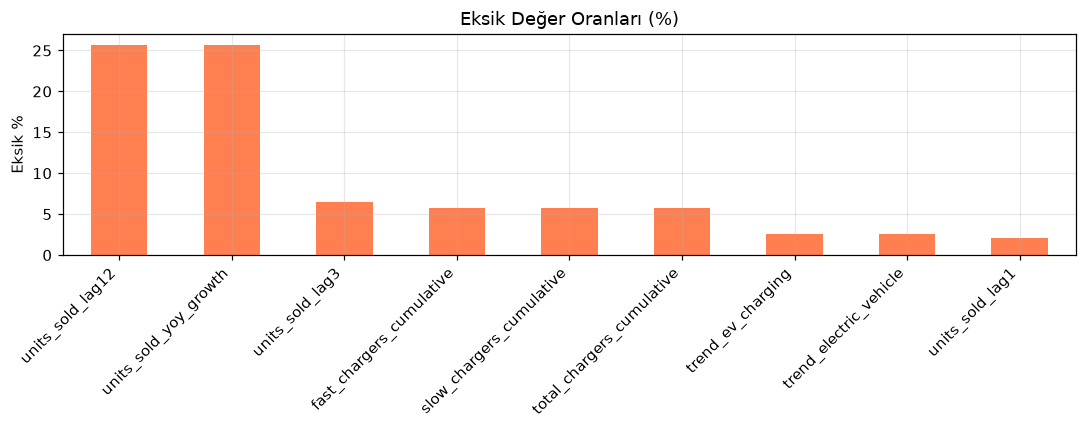

In [4]:
eksik = df.isnull().sum()
eksik_df = pd.DataFrame({'Eksik Sayı': eksik, 'Eksik %': (eksik / len(df) * 100).round(2)})
eksik_df = eksik_df[eksik_df['Eksik Sayı'] > 0].sort_values('Eksik %', ascending=False)
print(eksik_df)
print('\nŞarj verisi eksik olan ülke-dönemler:')
print(df[df['total_chargers_cumulative'].isna()].groupby('country')['date'].agg(['min', 'max', 'size']))

plt.figure(figsize=(10, 4))
eksik_df['Eksik %'].plot(kind='bar', color='coral')
plt.title('Eksik Değer Oranları (%)'); plt.ylabel('Eksik %'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.savefig('grafikler/01_eksik_deger.png', dpi=150, bbox_inches='tight'); plt.show()
SONUC['eksik'] = eksik_df['Eksik Sayı'].astype(int).to_dict()

## 2. Veri hazırlama
- Şarj ve arama trendi değişkenleri: ülke içinde zaman sırasına göre doğrusal interpolasyon (baş ve sondaki boşluklar en yakın değerle).
- `units_sold_roll3_prev`: **önceki** 3 ayın ortalaması (o ay dahil değil) → sızıntı yok.
- Gecikmeli satışı hesaplanamayan her serinin ilk 3 ayı çıkarılır.

In [5]:
df = df.sort_values(['seri', 'date']).reset_index(drop=True)

doldur = ['total_chargers_cumulative', 'slow_chargers_cumulative', 'fast_chargers_cumulative',
          'trend_ev_charging', 'trend_electric_vehicle']
df[doldur] = df.groupby('country')[doldur].transform(
    lambda s: s.interpolate(method='linear').ffill().bfill())

# Sızıntısız gecikmeli değişkenler (seri bazında)
g = df.groupby('seri')['units_sold']
df['units_sold_lag1'] = g.shift(1)
df['units_sold_lag3'] = g.shift(3)
df['units_sold_roll3_prev'] = g.transform(lambda s: s.shift(1).rolling(3, min_periods=3).mean())

# Sızıntı kontrolü: veri setindeki rolling3 o ayı içeriyor mu?
kendi = g.transform(lambda s: s.rolling(3, min_periods=1).mean())
print('Veri setindeki rolling3 o ayın satışını içeriyor mu?',
      np.allclose(kendi.values, df['units_sold_rolling3'].values))

df['country_enc'] = LabelEncoder().fit_transform(df['country'])
df['brand_enc'] = LabelEncoder().fit_transform(df['brand'])

Veri setindeki rolling3 o ayın satışını içeriyor mu? True


Model verisi: 393 satır (27 satır: serilerin ilk 3 ayı)
Kalan eksik: 0
Aykırı değer (3×IQR): 36 — silinmedi (Çin–BYD serisi doğal olarak çok yüksek)
seri
China – BYD    27
USA – Tesla     9
Name: count, dtype: int64

units_sold ile korelasyon:
units_sold_lag1                 0.983
units_sold_roll3_prev           0.975
units_sold_lag3                 0.951
total_chargers_cumulative       0.656
trend_byd                       0.496
year                            0.303
brand_enc                       0.227
trend_tesla                     0.201
quarter                         0.074
month                           0.071
trend_electric_car             -0.155
trend_ev_charging              -0.168
gasoline_price_usd_per_liter   -0.226
country_enc                    -0.295
Name: units_sold, dtype: float64


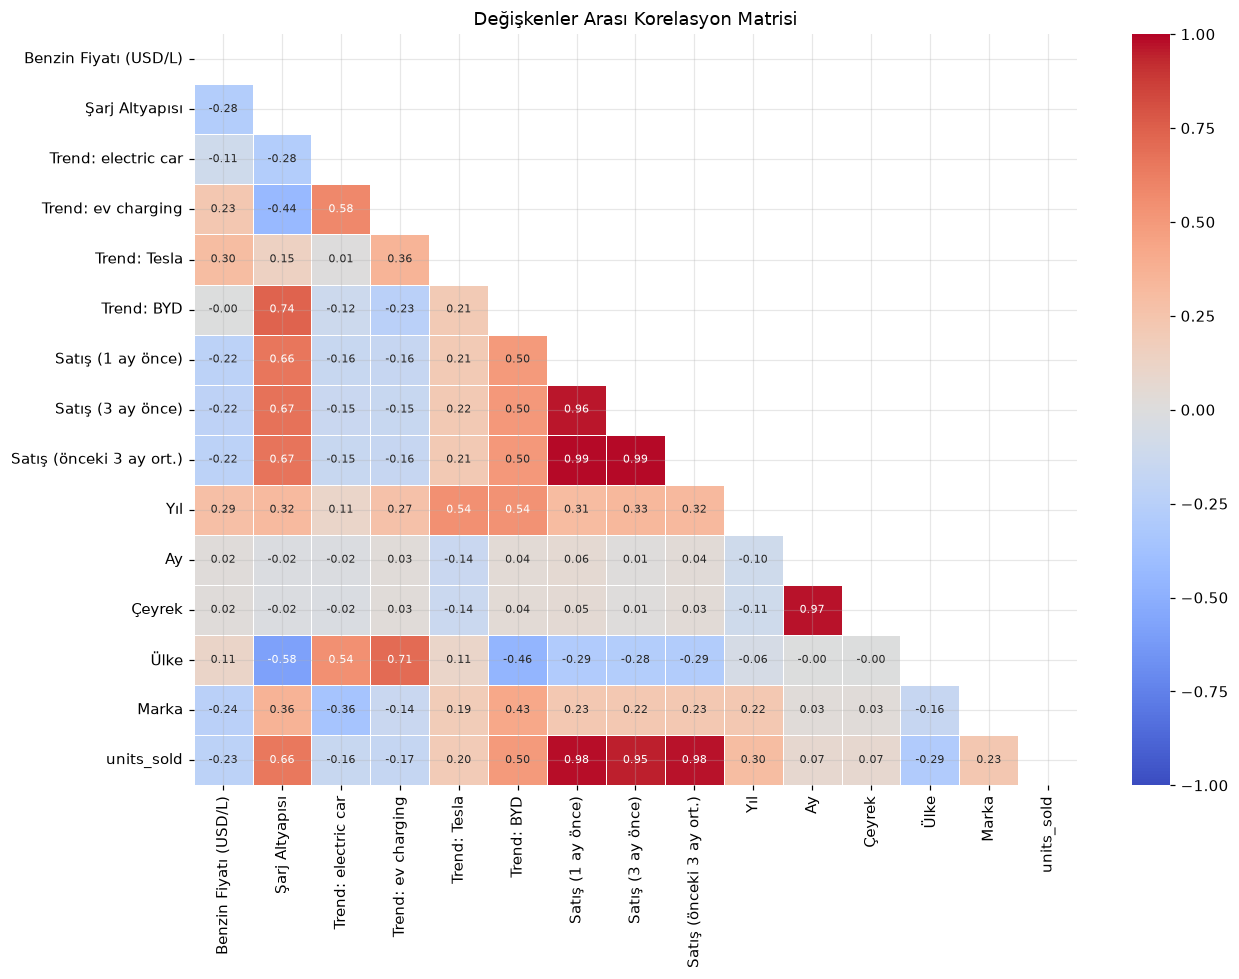

In [6]:
features = [
    'gasoline_price_usd_per_liter',   # Ana tedavi değişkeni
    'total_chargers_cumulative',      # Şarj altyapısı
    'trend_electric_car', 'trend_ev_charging', 'trend_tesla', 'trend_byd',
    'units_sold_lag1', 'units_sold_lag3', 'units_sold_roll3_prev',
    'year', 'month', 'quarter', 'country_enc', 'brand_enc',
]
target = 'units_sold'
etiket = {
    'gasoline_price_usd_per_liter': 'Benzin Fiyatı (USD/L)',
    'total_chargers_cumulative': 'Şarj Altyapısı',
    'trend_electric_car': 'Trend: electric car', 'trend_ev_charging': 'Trend: ev charging',
    'trend_tesla': 'Trend: Tesla', 'trend_byd': 'Trend: BYD',
    'units_sold_lag1': 'Satış (1 ay önce)', 'units_sold_lag3': 'Satış (3 ay önce)',
    'units_sold_roll3_prev': 'Satış (önceki 3 ay ort.)',
    'year': 'Yıl', 'month': 'Ay', 'quarter': 'Çeyrek', 'country_enc': 'Ülke', 'brand_enc': 'Marka',
}

df_ml = df.dropna(subset=['units_sold_lag1', 'units_sold_lag3', 'units_sold_roll3_prev']).copy()
print(f'Model verisi: {len(df_ml)} satır ({len(df) - len(df_ml)} satır: serilerin ilk 3 ayı)')
print('Kalan eksik:', int(df_ml[features].isnull().sum().sum()))

# Aykırı değer (3×IQR) — silinmiyor
Q1, Q3 = df_ml[target].quantile([.25, .75]); IQR = Q3 - Q1
aykiri = int(((df_ml[target] < Q1 - 3*IQR) | (df_ml[target] > Q3 + 3*IQR)).sum())
print('Aykırı değer (3×IQR):', aykiri, '— silinmedi (Çin–BYD serisi doğal olarak çok yüksek)')
print(df_ml.loc[(df_ml[target] > Q3 + 3*IQR), 'seri'].value_counts())

kor = df_ml[features + [target]].corr()[target].drop(target).sort_values(ascending=False)
print('\nunits_sold ile korelasyon:'); print(kor.round(3))

plt.figure(figsize=(12, 9))
cm = df_ml[features + [target]].rename(columns=etiket).corr()
sns.heatmap(cm, mask=np.triu(np.ones_like(cm, dtype=bool)), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1, linewidths=.5, annot_kws={'size': 7})
plt.title('Değişkenler Arası Korelasyon Matrisi'); plt.tight_layout()
plt.savefig('grafikler/02_korelasyon.png', dpi=150, bbox_inches='tight'); plt.show()

SONUC['hazirlik'] = {'model_satir': int(len(df_ml)), 'aykiri': aykiri,
                     'korelasyon': {etiket[k]: round(float(v), 3) for k, v in kor.items()}}

## 3. Makine öğrenmesi ile tahmin
**Zaman bölmesi:** 2019–2022 eğitim, 2023 test. Model hiçbir zaman geleceği görmez.

In [7]:
train = df_ml[df_ml['date'] < '2023-01-01'].sort_values(['date', 'seri'])
test = df_ml[df_ml['date'] >= '2023-01-01'].sort_values(['date', 'seri'])
X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]
print(f'Eğitim: {len(train)} satır ({train.date.min():%Y-%m} – {train.date.max():%Y-%m})')
print(f'Test  : {len(test)} satır ({test.date.min():%Y-%m} – {test.date.max():%Y-%m})')
print('Test setindeki seriler:', ', '.join(sorted(test['seri'].unique())))
SONUC['bolme'] = {'egitim': int(len(train)), 'test': int(len(test)),
                  'test_seri': sorted(test['seri'].unique().tolist())}

Eğitim: 297 satır (2019-04 – 2022-12)
Test  : 96 satır (2023-01 – 2023-12)
Test setindeki seriler: China – BYD, China – Tesla, France – All, India – All, Netherlands – All, Norway – BYD, USA – Tesla, United Kingdom – All


In [8]:
def metrik(y, p):
    return {'R2': r2_score(y, p), 'RMSE': float(np.sqrt(mean_squared_error(y, p))),
            'MAE': mean_absolute_error(y, p),
            'MAPE': float(np.mean(np.abs((y - p) / y)) * 100)}   # units_sold > 0 olduğu için +1 gerekmez

def yazdir(ad, m):
    print(f"{ad:<22} R²={m['R2']:.4f}  RMSE={m['RMSE']:>9,.0f}  MAE={m['MAE']:>9,.0f}  MAPE=%{m['MAPE']:.2f}")

modeller = {
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=5,
                                           min_samples_leaf=2, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8,
                                colsample_bytree=0.8, random_state=42, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8,
                                  subsample_freq=1, colsample_bytree=0.8, random_state=42, verbose=-1),
}

# Zaman bazlı doğrulama (eğitim seti içinde, ileriye doğru): 2021'i ve 2022'yi ayrı ayrı tahmin et
print('Zaman bazlı doğrulama (yalnızca eğitim verisiyle):')
cv = {}
for ad, m in modeller.items():
    skor = []
    for yil in [2021, 2022]:
        tr = train[train['year'] < yil]; va = train[train['year'] == yil]
        m.fit(tr[features], tr[target]); skor.append(r2_score(va[target], m.predict(va[features])))
    cv[ad] = skor
    print(f'  {ad:<14} R² 2021: {skor[0]:.3f} | 2022: {skor[1]:.3f} | ort: {np.mean(skor):.3f}')

# Nihai eğitim ve test
sonuc, tahmin = {}, {}
tahmin['Naif (geçen ay)'] = X_test['units_sold_lag1'].values
sonuc['Naif (geçen ay)'] = metrik(y_test, tahmin['Naif (geçen ay)'])
print('\nTest seti (2023):')
yazdir('Naif (geçen ay)', sonuc['Naif (geçen ay)'])
onem = {}
for ad, m in modeller.items():
    m.fit(X_train, y_train)
    tahmin[ad] = m.predict(X_test); sonuc[ad] = metrik(y_test, tahmin[ad]); yazdir(ad, sonuc[ad])
    imp = pd.Series(m.feature_importances_, index=features)
    onem[ad] = (imp / imp.sum()).sort_values(ascending=False)

sonuc_df = pd.DataFrame(sonuc).T
SONUC['ml'] = {k: {kk: float(vv) for kk, vv in v.items()} for k, v in sonuc.items()}
SONUC['cv'] = {k: [float(x) for x in v] for k, v in cv.items()}

Zaman bazlı doğrulama (yalnızca eğitim verisiyle):


  Random Forest  R² 2021: 0.318 | 2022: 0.519 | ort: 0.418


  XGBoost        R² 2021: 0.348 | 2022: 0.568 | ort: 0.458
  LightGBM       R² 2021: -0.003 | 2022: 0.300 | ort: 0.148

Test seti (2023):
Naif (geçen ay)        R²=0.9675  RMSE=   30,681  MAE=    6,916  MAPE=%6.42


Random Forest          R²=0.9655  RMSE=   31,633  MAE=   15,085  MAPE=%14.67
XGBoost                R²=0.9427  RMSE=   40,744  MAE=   16,593  MAPE=%23.79


LightGBM               R²=0.8425  RMSE=   67,565  MAE=   35,869  MAPE=%83.47


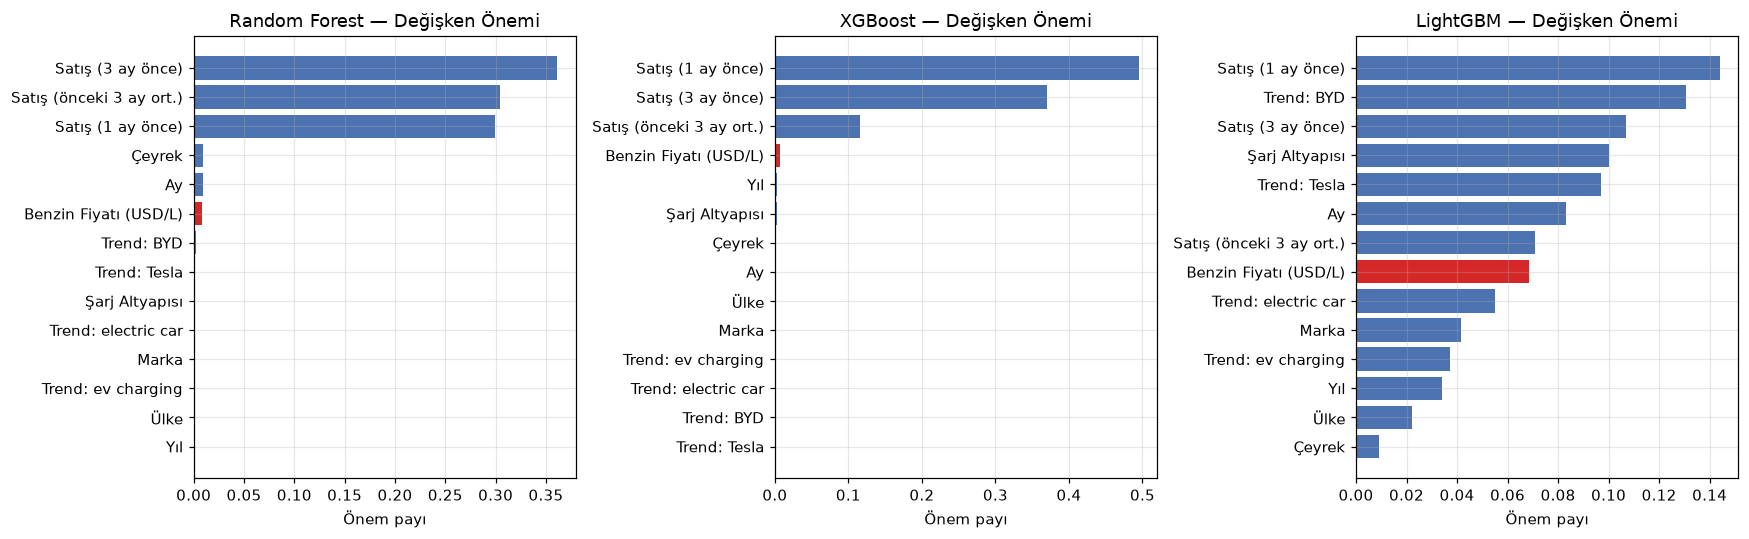

Random Forest: en önemli [('Satış (3 ay önce)', 36.1), ('Satış (önceki 3 ay ort.)', 30.5), ('Satış (1 ay önce)', 29.9)] | benzin fiyatı 6. sırada (%0.8)
XGBoost: en önemli [('Satış (1 ay önce)', 49.5), ('Satış (3 ay önce)', 37.0), ('Satış (önceki 3 ay ort.)', 11.5)] | benzin fiyatı 4. sırada (%0.7)
LightGBM: en önemli [('Satış (1 ay önce)', 14.4), ('Trend: BYD', 13.0), ('Satış (3 ay önce)', 10.7)] | benzin fiyatı 8. sırada (%6.9)


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, ad in zip(axes, modeller):
    o = onem[ad].rename(index=etiket)
    renk = ['#d62728' if i == 'Benzin Fiyatı (USD/L)' else '#4c72b0' for i in o.index]
    ax.barh(o.index[::-1], o.values[::-1], color=renk[::-1])
    ax.set_title(f'{ad} — Değişken Önemi'); ax.set_xlabel('Önem payı')
plt.tight_layout(); plt.savefig('grafikler/03_degisken_onemi.png', dpi=150, bbox_inches='tight'); plt.show()

SONUC['onem'] = {}
for ad in modeller:
    o = onem[ad]
    sira = int(list(o.index).index('gasoline_price_usd_per_liter')) + 1   # (orijinal kodda hatalıydı)
    SONUC['onem'][ad] = {'ilk3': [(etiket[i], round(float(v) * 100, 1)) for i, v in o.head(3).items()],
                         'benzin_sira': sira, 'benzin_pay': round(float(o['gasoline_price_usd_per_liter']) * 100, 1)}
    print(f"{ad}: en önemli {SONUC['onem'][ad]['ilk3']} | benzin fiyatı {sira}. sırada (%{SONUC['onem'][ad]['benzin_pay']})")

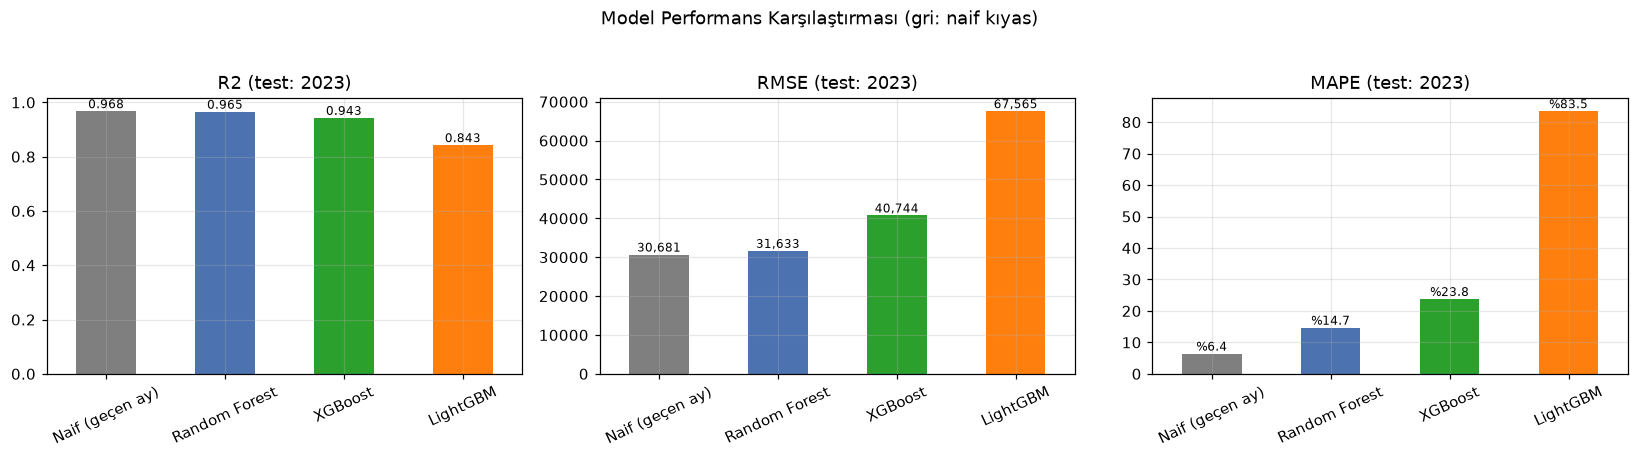

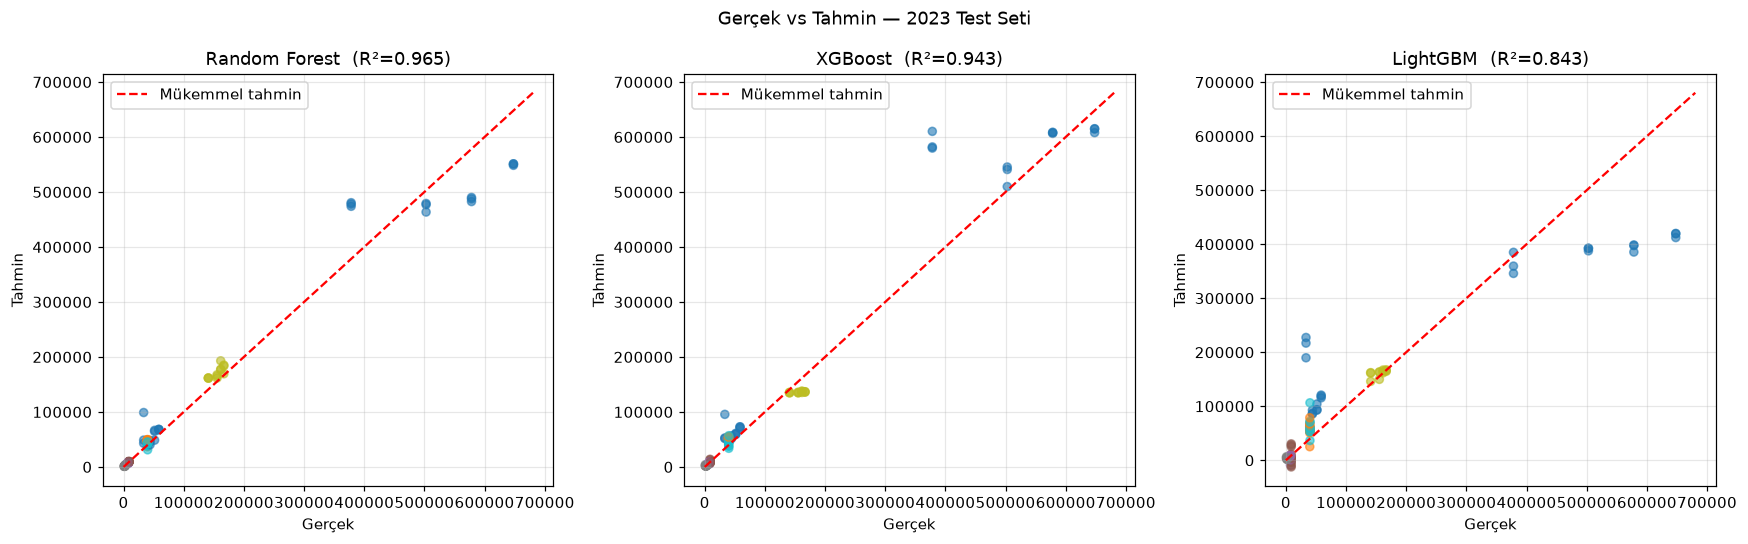

En iyi ML modeli: Random Forest

                      ort_gercek      MAE  MAPE_%
seri                                             
China – BYD             526859.0  79552.0    15.8
China – Tesla            46934.0  13254.3    33.3
France – All             39704.0   6893.0    17.4
India – All               7536.0    597.9     7.9
Netherlands – All         8824.0    418.7     4.7
Norway – BYD              2133.0    413.5    18.9
USA – Tesla             156126.5  15945.6    10.3
United Kingdom – All     40000.0   3606.0     9.0


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
renk = ['#7f7f7f', '#4c72b0', '#2ca02c', '#ff7f0e']
for ax, met in zip(axes, ['R2', 'RMSE', 'MAPE']):
    sonuc_df[met].plot(kind='bar', ax=ax, color=renk)
    ax.set_title(f'{met} (test: 2023)'); ax.tick_params(axis='x', rotation=25)
    for i, v in enumerate(sonuc_df[met]):
        ax.text(i, v, f'{v:.3f}' if met == 'R2' else f'{v:,.0f}' if met == 'RMSE' else f'%{v:.1f}',
                ha='center', va='bottom', fontsize=8)
plt.suptitle('Model Performans Karşılaştırması (gri: naif kıyas)', y=1.03)
plt.tight_layout(); plt.savefig('grafikler/04_model_karsilastirma.png', dpi=150, bbox_inches='tight'); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, ad in zip(axes, modeller):
    ax.scatter(y_test, tahmin[ad], alpha=.6, s=28, c=test['country_enc'], cmap='tab10')
    lo, hi = 0, max(y_test.max(), tahmin[ad].max()) * 1.05
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Mükemmel tahmin')
    ax.set_xlabel('Gerçek'); ax.set_ylabel('Tahmin'); ax.set_title(f"{ad}  (R²={sonuc[ad]['R2']:.3f})"); ax.legend()
plt.suptitle('Gerçek vs Tahmin — 2023 Test Seti'); plt.tight_layout()
plt.savefig('grafikler/05_gercek_tahmin.png', dpi=150, bbox_inches='tight'); plt.show()

# Seri bazında hata (hangi seride zorlanıyor?)
en_iyi = max(modeller, key=lambda a: sonuc[a]['R2'])
seri_hata = test.assign(tahmin=tahmin[en_iyi]).groupby('seri').apply(
    lambda d: pd.Series({'ort_gercek': d[target].mean(), 'MAE': mean_absolute_error(d[target], d['tahmin']),
                         'MAPE_%': np.mean(np.abs(d[target] - d['tahmin']) / d[target]) * 100}))
print(f'En iyi ML modeli: {en_iyi}\n'); print(seri_hata.round(1))
SONUC['en_iyi'] = en_iyi
SONUC['seri_hata'] = seri_hata.round(1).to_dict(orient='index')

## 4. Açıklanabilir yapay zekâ (SHAP)
En iyi ML modeli üzerinde, 2023 test gözlemleri için.

Ortalama |SHAP| (test, birim):
  Satış (1 ay önce)               32,567   yön (değer↑→SHAP): +0.94
  Satış (3 ay önce)               31,817   yön (değer↑→SHAP): +0.97
  Satış (önceki 3 ay ort.)        30,110   yön (değer↑→SHAP): +0.99
  Çeyrek                           1,426   yön (değer↑→SHAP): +0.39
  Ay                               1,344   yön (değer↑→SHAP): +0.37
  Benzin Fiyatı (USD/L)            1,138   yön (değer↑→SHAP): -0.27
  Şarj Altyapısı                     716   yön (değer↑→SHAP): +0.47
  Trend: BYD                         553   yön (değer↑→SHAP): +0.79
  Trend: ev charging                 316   yön (değer↑→SHAP): +0.21
  Trend: Tesla                       287   yön (değer↑→SHAP): -0.36
  Yıl                                258   yön (değer↑→SHAP): +nan
  Ülke                               234   yön (değer↑→SHAP): -0.65
  Trend: electric car                229   yön (değer↑→SHAP): +0.19
  Marka                              229   yön (değer↑→SHAP): -0.62


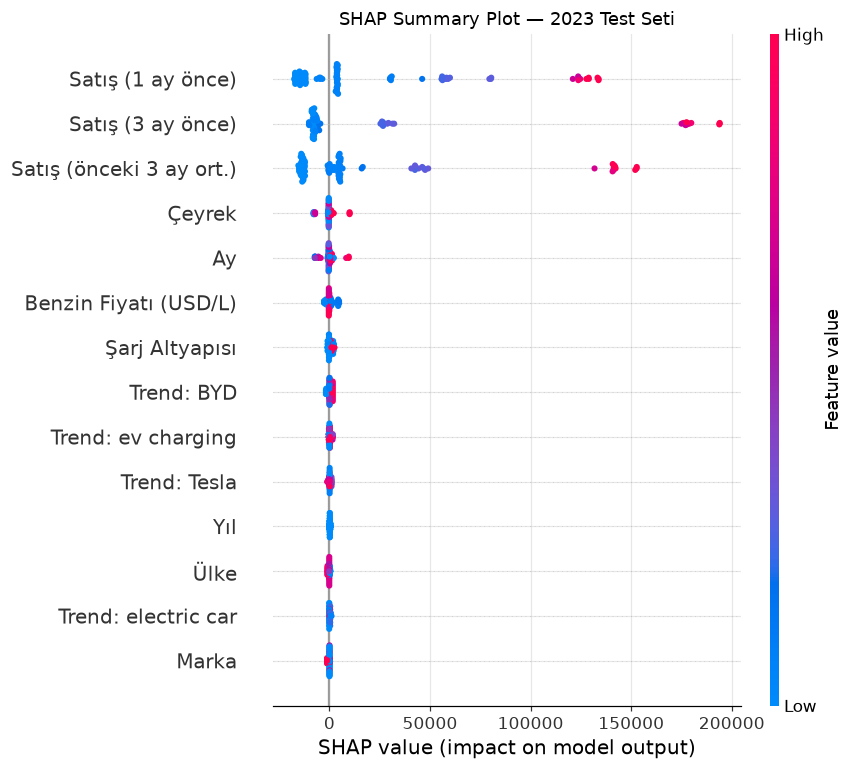

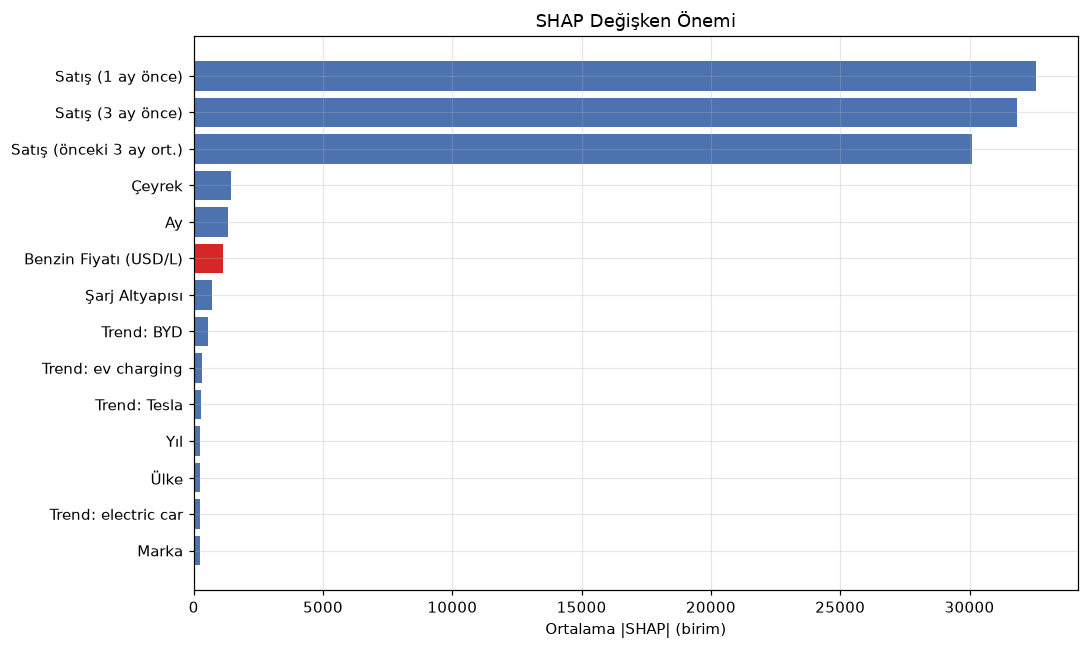

In [11]:
model = modeller[en_iyi]
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
base = float(np.ravel(explainer.expected_value)[0])
isimler = [etiket[f] for f in features]

ort_shap = pd.Series(np.abs(shap_values).mean(0), index=isimler).sort_values(ascending=False)
yon = pd.Series([np.corrcoef(X_test[f], shap_values[:, i])[0, 1] if X_test[f].std() > 0 else np.nan
                 for i, f in enumerate(features)], index=isimler)
print('Ortalama |SHAP| (test, birim):')
for k, v in ort_shap.items():
    print(f'  {k:<28} {v:>9,.0f}   yön (değer↑→SHAP): {yon[k]:+.2f}')
SONUC['shap'] = {'base': base, 'sira': [(k, float(v), float(yon[k])) for k, v in ort_shap.items()]}

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=isimler, show=False, max_display=14)
plt.title('SHAP Summary Plot — 2023 Test Seti'); plt.tight_layout()
plt.savefig('grafikler/06_shap_summary.png', dpi=150, bbox_inches='tight'); plt.show()

plt.figure(figsize=(10, 6))
renk = ['#d62728' if k.startswith('Benzin') else '#4c72b0' for k in ort_shap.index]
plt.barh(ort_shap.index[::-1], ort_shap.values[::-1], color=renk[::-1])
plt.xlabel('Ortalama |SHAP| (birim)'); plt.title('SHAP Değişken Önemi'); plt.tight_layout()
plt.savefig('grafikler/07_shap_bar.png', dpi=150, bbox_inches='tight'); plt.show()

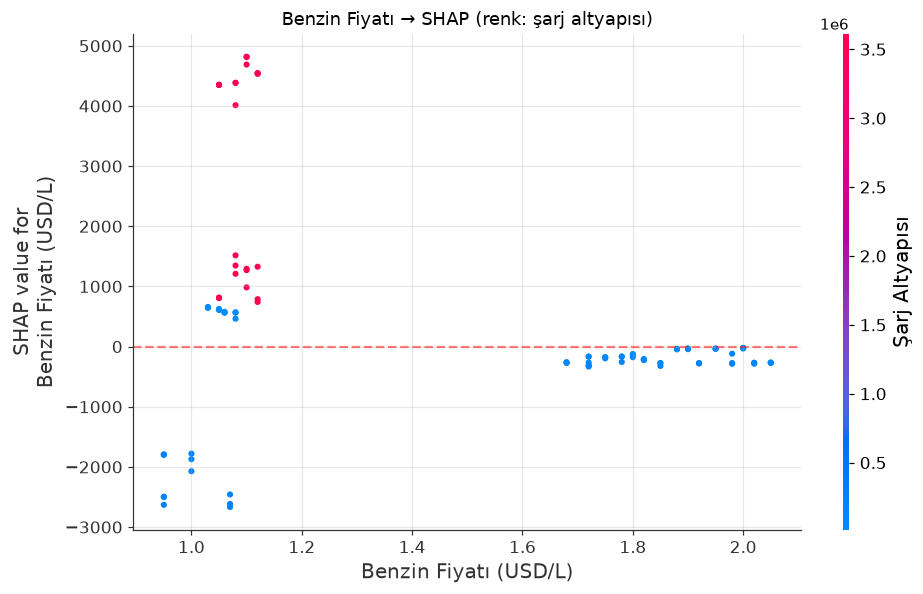

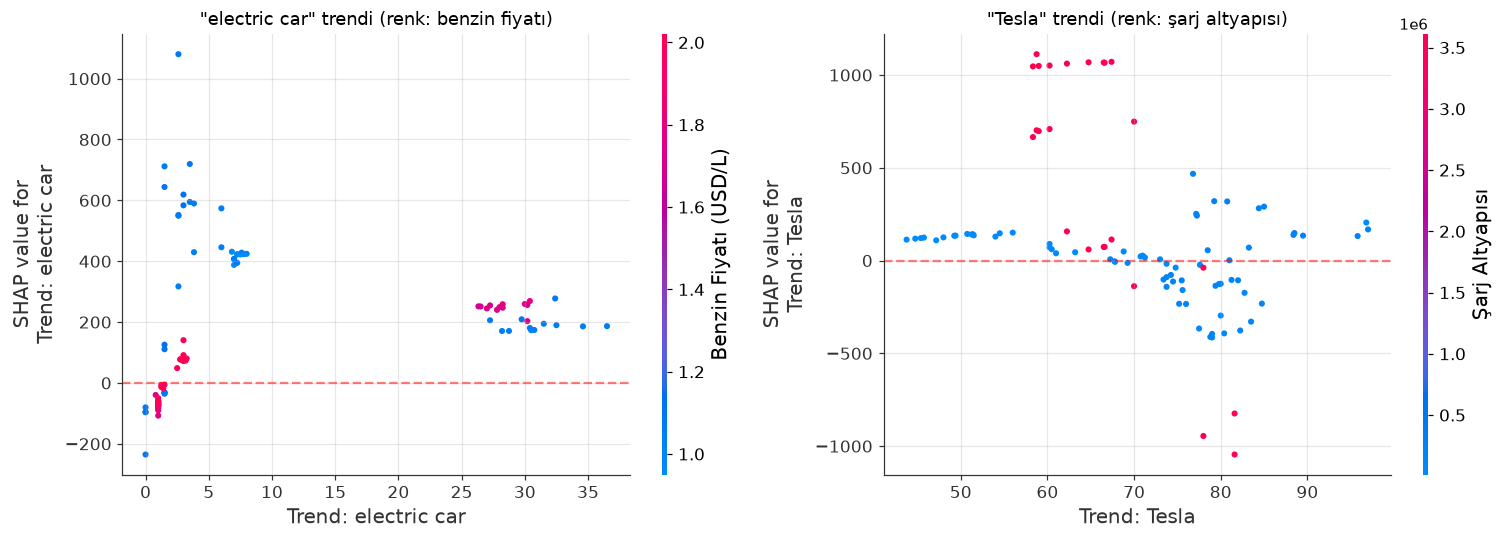

{'kor_fiyat_shap': -0.2659333506540546, 'ort_shap_yuksek_sarj': 771.5373866658629, 'ort_shap_dusuk_sarj': 25.262196613996807}


In [12]:
gi, ci, ti, tsi = (features.index(f) for f in ['gasoline_price_usd_per_liter', 'total_chargers_cumulative',
                                               'trend_electric_car', 'trend_tesla'])
fig, ax = plt.subplots(figsize=(9, 5.5))
shap.dependence_plot(gi, shap_values, X_test, feature_names=isimler, interaction_index=ci, ax=ax, show=False)
ax.axhline(0, color='red', ls='--', alpha=.5); ax.set_title('Benzin Fiyatı → SHAP (renk: şarj altyapısı)')
plt.tight_layout(); plt.savefig('grafikler/08_dependence_benzin.png', dpi=150, bbox_inches='tight'); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
shap.dependence_plot(ti, shap_values, X_test, feature_names=isimler, interaction_index=gi, ax=axes[0], show=False)
shap.dependence_plot(tsi, shap_values, X_test, feature_names=isimler, interaction_index=ci, ax=axes[1], show=False)
for a in axes: a.axhline(0, color='red', ls='--', alpha=.5)
axes[0].set_title('"electric car" trendi (renk: benzin fiyatı)'); axes[1].set_title('"Tesla" trendi (renk: şarj altyapısı)')
plt.tight_layout(); plt.savefig('grafikler/09_dependence_trend.png', dpi=150, bbox_inches='tight'); plt.show()

# Benzin fiyatı SHAP'ının şarj altyapısına göre değişimi (etkileşim iddiasını sayıyla kontrol)
sv_g = shap_values[:, gi]
yuksek_sarj = X_test['total_chargers_cumulative'] >= X_test['total_chargers_cumulative'].median()
SONUC['shap_benzin'] = {
    'kor_fiyat_shap': float(np.corrcoef(X_test['gasoline_price_usd_per_liter'], sv_g)[0, 1]),
    'ort_shap_yuksek_sarj': float(sv_g[yuksek_sarj.values].mean()),
    'ort_shap_dusuk_sarj': float(sv_g[~yuksek_sarj.values].mean())}
print(SONUC['shap_benzin'])

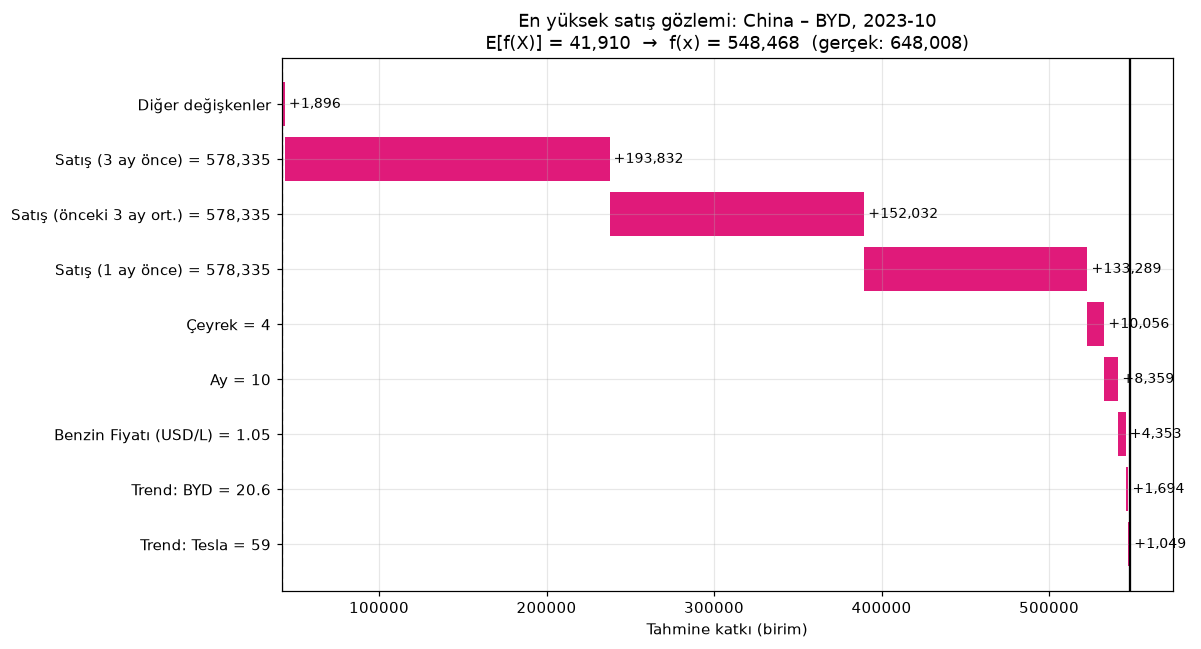

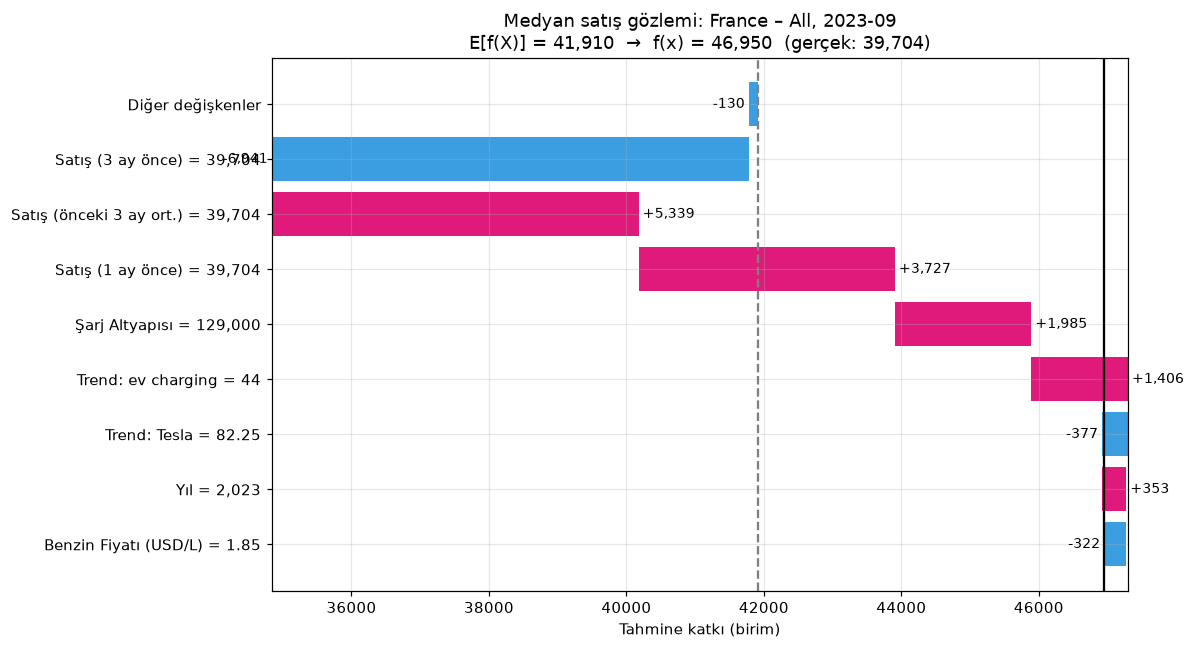

{
 "en_yuksek": {
  "seri": "China – BYD",
  "tarih": "2023-10",
  "gercek": 648008.0,
  "tahmin": 548467.9590714289,
  "katkilar": {
   "Satış (3 ay önce)": 193831.70886116728,
   "Satış (önceki 3 ay ort.)": 152031.82626643268,
   "Satış (1 ay önce)": 133288.5444095459,
   "Çeyrek": 10055.57660951029,
   "Ay": 8358.760303954046
  },
  "benzin": 1.05,
  "benzin_shap": 4352.966027225196
 },
 "medyan": {
  "seri": "France – All",
  "tarih": "2023-09",
  "gercek": 39704.0,
  "tahmin": 46950.356203548065,
  "katkilar": {
   "Satış (3 ay önce)": -6940.982467168732,
   "Satış (önceki 3 ay ort.)": 5339.135401127136,
   "Satış (1 ay önce)": 3727.312430451413,
   "Şarj Altyapısı": 1984.9200225404697,
   "Trend: ev charging": 1406.3229849746597
  },
  "benzin": 1.85,
  "benzin_shap": -322.49054856958435
 }
}


In [13]:
def waterfall(i, baslik, dosya):
    sv = shap_values[i]; veri = X_test.iloc[i]
    sira = np.argsort(np.abs(sv))[::-1]; ust = sira[:8]; diger = sv[sira[8:]].sum()
    vals = list(sv[ust][::-1]) + [diger]; fmt = lambda v: f'{v:,.0f}' if abs(v) >= 1000 else f'{v:g}'
    adlar = [f'{isimler[j]} = {fmt(veri.iloc[j])}' for j in ust[::-1]] + ['Diğer değişkenler']
    vals, adlar = vals[::-1], adlar[::-1]
    fig, ax = plt.subplots(figsize=(11, 6)); bas = base
    for k, (v, a) in enumerate(zip(vals, adlar)):
        ax.barh(k, v, left=bas, color='#E01A7A' if v > 0 else '#3B9EE0')
        ax.text(bas + v, k, f' {v:+,.0f} ', va='center', ha='left' if v > 0 else 'right', fontsize=9)
        bas += v
    ax.set_yticks(range(len(adlar))); ax.set_yticklabels(adlar); ax.invert_yaxis()
    ax.axvline(base, color='gray', ls='--'); ax.axvline(bas, color='black')
    ax.set_title(f'{baslik}\nE[f(X)] = {base:,.0f}  →  f(x) = {bas:,.0f}  (gerçek: {y_test.iloc[i]:,.0f})')
    ax.set_xlabel('Tahmine katkı (birim)'); plt.tight_layout()
    plt.savefig(dosya, dpi=150, bbox_inches='tight'); plt.show()
    return {'seri': test['seri'].iloc[i], 'tarih': f"{test['date'].iloc[i]:%Y-%m}", 'gercek': float(y_test.iloc[i]),
            'tahmin': float(bas), 'katkilar': {isimler[j]: float(sv[j]) for j in sira[:5]},
            'benzin': float(veri['gasoline_price_usd_per_liter']), 'benzin_shap': float(sv[gi])}

i_max = int(np.argmax(y_test.values))
i_med = int(np.argsort(y_test.values)[len(y_test) // 2])
SONUC['waterfall'] = {
    'en_yuksek': waterfall(i_max, f"En yüksek satış gözlemi: {test['seri'].iloc[i_max]}, {test['date'].iloc[i_max]:%Y-%m}",
                           'grafikler/10_waterfall_en_yuksek.png'),
    'medyan': waterfall(i_med, f"Medyan satış gözlemi: {test['seri'].iloc[i_med]}, {test['date'].iloc[i_med]:%Y-%m}",
                        'grafikler/11_waterfall_medyan.png')}
print(json.dumps(SONUC['waterfall'], ensure_ascii=False, indent=1))

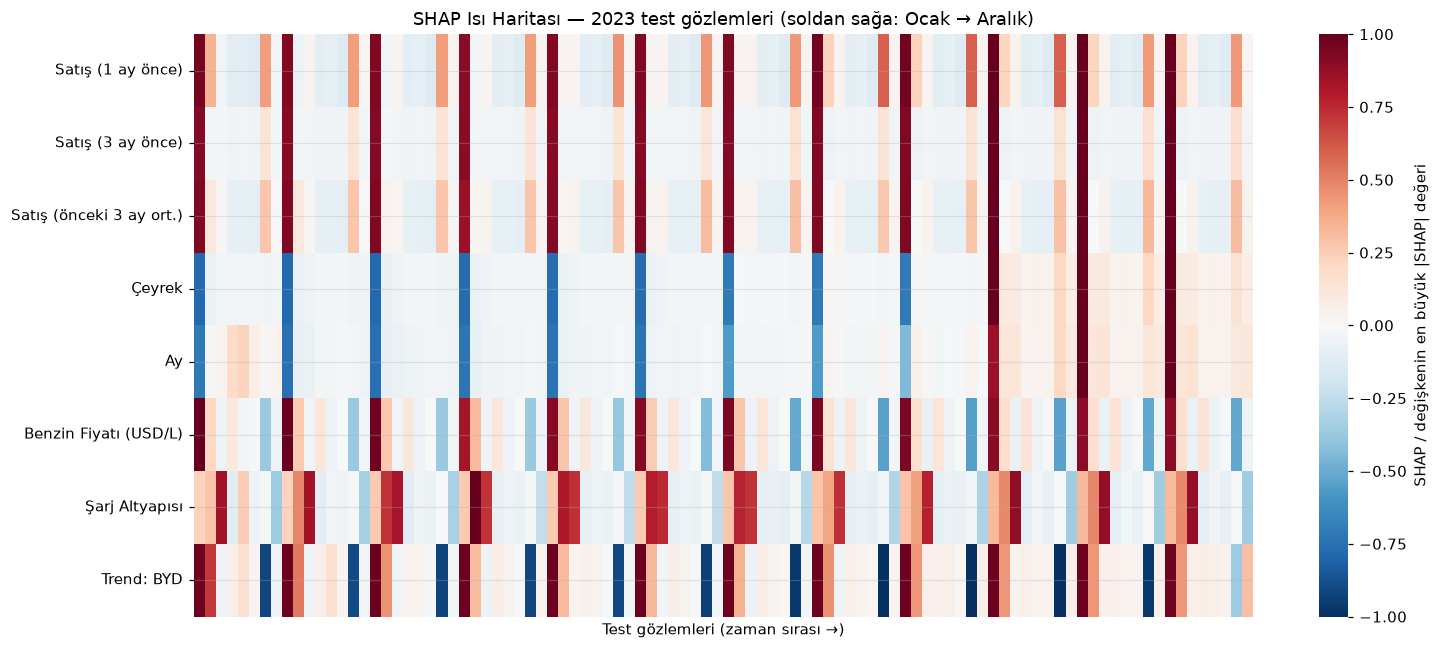

Benzin fiyatı SHAP — aylara göre ortalama (2023):
ay              1      2      3      4      5      6      7      8      9   \
benzin_shap  473.0  525.0  513.0  450.0  464.0  423.0  415.0  322.0  312.0   

ay              10     11     12  
benzin_shap  284.0  300.0  301.0  


In [14]:
# SHAP ısı haritası: sütunlar zaman sırasına göre (test seti tarih sıralı)
ust8 = ort_shap.head(8).index
sdf = pd.DataFrame(shap_values, columns=isimler)[ust8]
plt.figure(figsize=(14, 6))
sns.heatmap((sdf / sdf.abs().max()).T, cmap='RdBu_r', center=0, xticklabels=False,
            cbar_kws={'label': 'SHAP / değişkenin en büyük |SHAP| değeri'})
plt.title('SHAP Isı Haritası — 2023 test gözlemleri (soldan sağa: Ocak → Aralık)')
plt.xlabel('Test gözlemleri (zaman sırası →)'); plt.tight_layout()
plt.savefig('grafikler/12_shap_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()
aylik = pd.DataFrame(shap_values[:, gi], columns=['benzin_shap']).assign(ay=test['month'].values).groupby('ay').mean()
print('Benzin fiyatı SHAP — aylara göre ortalama (2023):'); print(aylik.round(0).T)
SONUC['shap_benzin_aylik'] = aylik['benzin_shap'].round(0).to_dict()

## 5. Nedensellik analizi
- **Y:** `units_sold` (aylık satış, birim) · **T:** benzin fiyatı (USD/L)
- **X (karıştırıcılar/heterojenlik):** şarj altyapısı, arama trendleri (electric car, Tesla, BYD), yıl, ay, çeyrek, ülke, marka
- Etki birimi: **benzin fiyatındaki 1 USD/L artışın aylık satışa etkisi (birim)**
- Tüm 420 gözlem kullanılır (gecikmeli değişken gerekmediği için).

Y ort: 54,029 birim | T ort: 1.38 USD/L | karıştırıcı: 9 | gözlem: 420


LinearDML ortalama nedensel etki (ATE): -2,101 birim / +1 USD/L
95% güven aralığı: [-49,083, +44,882]
Not: dml.coef_[0] = -0.04 → bu ATE değil, şarj altyapısının etkiyi nasıl değiştirdiğinin katsayısıdır (orijinal kodda raporlanan sayı).


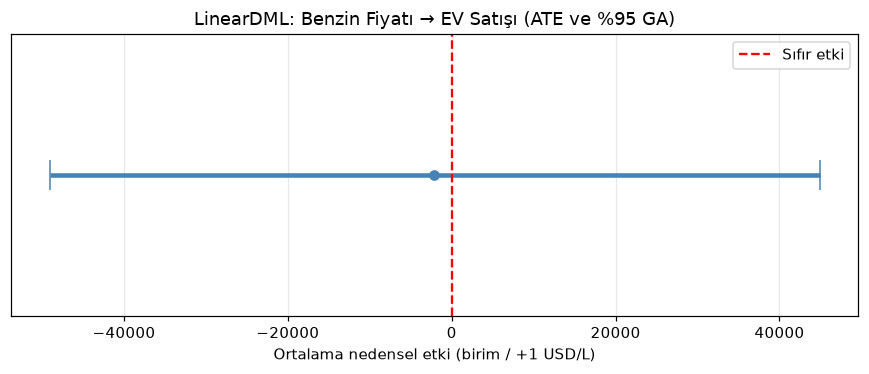

In [15]:
conf = ['total_chargers_cumulative', 'trend_electric_car', 'trend_tesla', 'trend_byd',
        'year', 'month', 'quarter', 'country_enc', 'brand_enc']
conf_ad = [etiket[c] for c in conf]
dc = df.copy()
Y = dc[target].values; T = dc['gasoline_price_usd_per_liter'].values; X = dc[conf].values
print(f'Y ort: {Y.mean():,.0f} birim | T ort: {T.mean():.2f} USD/L | karıştırıcı: {len(conf)} | gözlem: {len(Y)}')

dml = LinearDML(model_y=RandomForestRegressor(n_estimators=200, random_state=42),
                model_t=RandomForestRegressor(n_estimators=200, random_state=42),
                random_state=42, cv=5)
dml.fit(Y, T, X=X)
ate = float(dml.ate(X)); ate_lb, ate_ub = (float(v) for v in dml.ate_interval(X, alpha=0.05))
print(f'LinearDML ortalama nedensel etki (ATE): {ate:+,.0f} birim / +1 USD/L')
print(f'95% güven aralığı: [{ate_lb:+,.0f}, {ate_ub:+,.0f}]')
print('Not: dml.coef_[0] =', round(float(dml.coef_[0]), 4),
      '→ bu ATE değil, şarj altyapısının etkiyi nasıl değiştirdiğinin katsayısıdır (orijinal kodda raporlanan sayı).')
SONUC['lineardml'] = {'ate': ate, 'lb': ate_lb, 'ub': ate_ub, 'eski_coef0': float(dml.coef_[0])}

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.errorbar([ate], [0], xerr=[[ate - ate_lb], [ate_ub - ate]], fmt='o', capsize=10, lw=3, color='steelblue')
ax.axvline(0, color='red', ls='--', label='Sıfır etki'); ax.set_yticks([])
ax.set_xlabel('Ortalama nedensel etki (birim / +1 USD/L)'); ax.legend()
ax.set_title('LinearDML: Benzin Fiyatı → EV Satışı (ATE ve %95 GA)')
plt.tight_layout(); plt.savefig('grafikler/13_lineardml.png', dpi=150, bbox_inches='tight'); plt.show()

In [16]:
cf = CausalForestDML(n_estimators=400, min_samples_leaf=5, random_state=42, cv=5, verbose=0)
cf.fit(Y, T, X=X)
dc['cate'] = cf.effect(X)
lb, ub = cf.effect_interval(X, alpha=0.10)
dc['cate_lb'], dc['cate_ub'] = lb, ub
cf_ate = float(cf.ate(X)); cf_lb, cf_ub = (float(v) for v in cf.ate_interval(X, alpha=0.05))
anlamli = float(((lb > 0) | (ub < 0)).mean() * 100)
print(f'Causal Forest ATE: {cf_ate:+,.0f} birim / +1 USD/L, 95% GA [{cf_lb:+,.0f}, {cf_ub:+,.0f}]')
print(f"CATE dağılımı: ort {dc['cate'].mean():+,.0f} | std {dc['cate'].std():,.0f} | min {dc['cate'].min():+,.0f} | max {dc['cate'].max():+,.0f}")
print(f'%90 güven aralığı sıfırı DIŞLAYAN gözlem oranı: %{anlamli:.1f}')
SONUC['cf'] = {'ate': cf_ate, 'lb': cf_lb, 'ub': cf_ub, 'ort': float(dc.cate.mean()), 'std': float(dc.cate.std()),
               'min': float(dc.cate.min()), 'max': float(dc.cate.max()), 'anlamli_oran': anlamli}

Causal Forest ATE: +3,794 birim / +1 USD/L, 95% GA [-23,062, +30,651]
CATE dağılımı: ort +3,794 | std 11,961 | min -57,654 | max +47,572
%90 güven aralığı sıfırı DIŞLAYAN gözlem oranı: %3.6


Seri bazında ortalama CATE (birim / +1 USD/L):
                        CATE      alt      ust   n
seri                                              
China – BYD           9745.0 -32184.0  51674.0  48
Germany – VW          6694.0  -3805.0  17192.0  24
Norway – BYD          5454.0  -3349.0  14256.0  24
France – All          3480.0  -3827.0  10787.0  60
Netherlands – All     3337.0  -5930.0  12604.0  60
India – All           3163.0  -5039.0  11366.0  60
USA – Tesla           2690.0  -9766.0  15146.0  48
United Kingdom – All  1689.0  -5180.0   8557.0  60
China – Tesla          141.0 -44065.0  44348.0  36


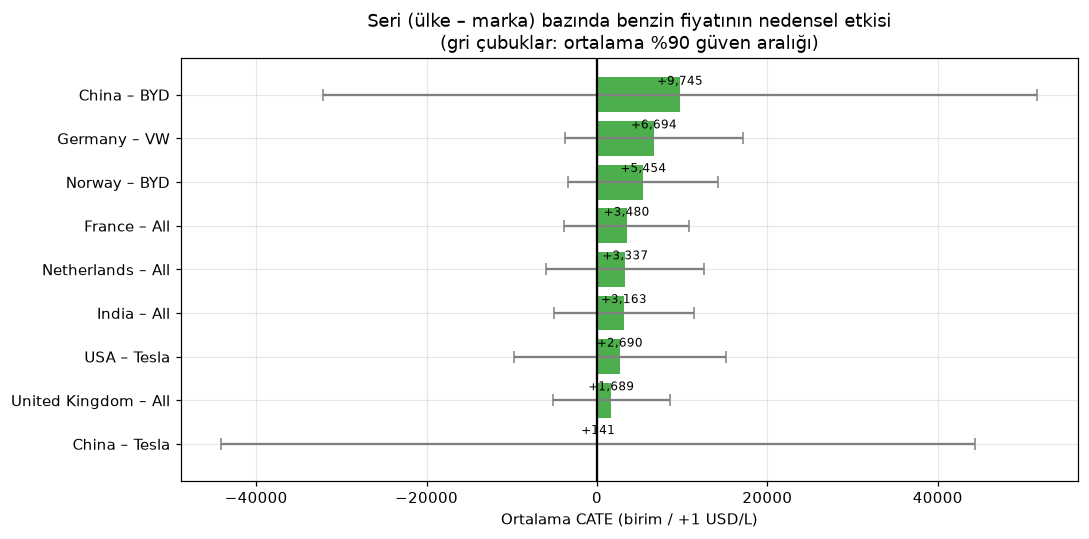


Yıl bazında:
        CATE      alt      ust    n
year                               
2019  1695.0  -3907.0   7296.0   48
2020  5354.0  -3572.0  14279.0   72
2021  9437.0  -7356.0  26230.0   96
2022  3846.0 -13303.0  20994.0  108
2023 -2025.0 -24819.0  20768.0   96


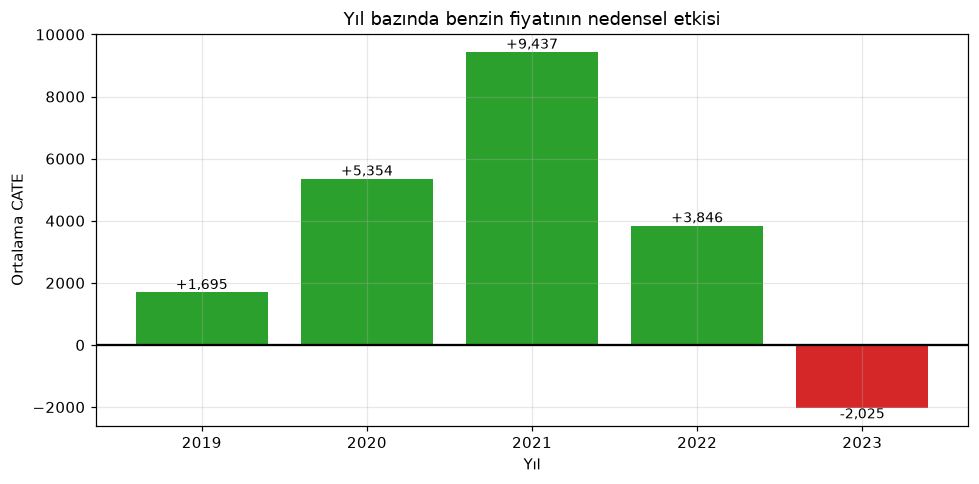


Benzin fiyatı grubuna göre:
               CATE      alt      ust    n     aralik
benzin_grup                                          
Düşük        6465.0 -10209.0  23140.0  105  0.47–1.06
Orta-Düşük   1249.0 -27670.0  30169.0  105  1.06–1.31
Orta-Yüksek  3490.0  -4073.0  11052.0  105  1.31–1.73
Yüksek       3973.0  -5384.0  13329.0  105  1.73–2.38
Bu gruplardaki seriler:
seri         China – BYD  China – Tesla  France – All  Germany – VW  \
benzin_grup                                                           
Düşük                 21              9             0             0   
Orta-Düşük            27             27             3             0   
Orta-Yüksek            0              0            36            12   
Yüksek                 0              0            21            12   

seri         India – All  Netherlands – All  Norway – BYD  USA – Tesla  \
benzin_grup                                                              
Düşük                 39                  0     

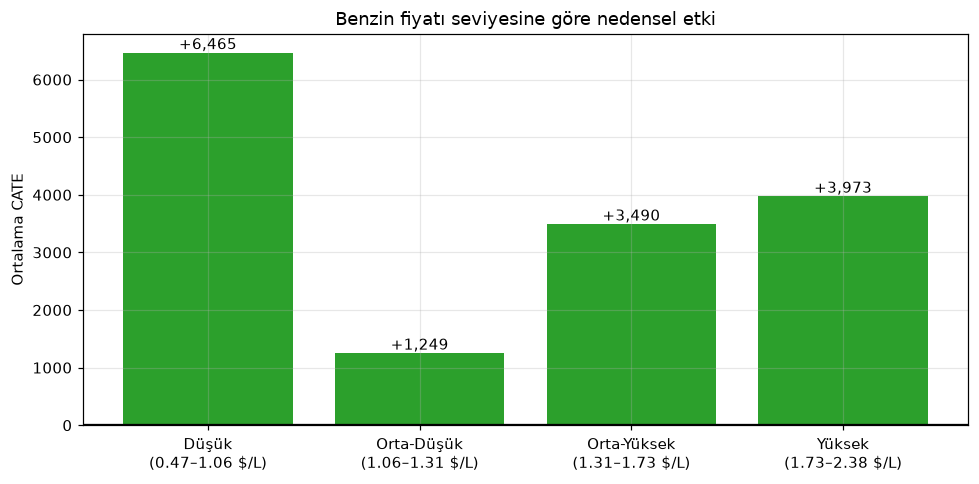

In [17]:
def grup_ozet(by):
    return dc.groupby(by, observed=True).agg(CATE=('cate', 'mean'), alt=('cate_lb', 'mean'),
                                             ust=('cate_ub', 'mean'), n=('cate', 'size'))

ulke = grup_ozet('seri').sort_values('CATE', ascending=False)
print('Seri bazında ortalama CATE (birim / +1 USD/L):'); print(ulke.round(0))
fig, ax = plt.subplots(figsize=(10, 5))
u = ulke[::-1]
ax.barh(u.index, u['CATE'], xerr=[u['CATE'] - u['alt'], u['ust'] - u['CATE']], capsize=4, ecolor='gray',
        color=['#2ca02c' if v > 0 else '#d62728' for v in u['CATE']], alpha=.85)
ax.axvline(0, color='black'); ax.set_xlabel('Ortalama CATE (birim / +1 USD/L)')
ax.set_title('Seri (ülke – marka) bazında benzin fiyatının nedensel etkisi\n(gri çubuklar: ortalama %90 güven aralığı)')
for k, v in enumerate(u['CATE']): ax.text(v, k + .3, f'{v:+,.0f}', va='center', ha='center', fontsize=8)
plt.tight_layout(); plt.savefig('grafikler/14_cate_seri.png', dpi=150, bbox_inches='tight'); plt.show()

yil = grup_ozet('year'); print('\nYıl bazında:'); print(yil.round(0))
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(yil.index, yil['CATE'], color=['#2ca02c' if v > 0 else '#d62728' for v in yil['CATE']])
ax.axhline(0, color='black'); ax.set_xlabel('Yıl'); ax.set_ylabel('Ortalama CATE')
ax.set_title('Yıl bazında benzin fiyatının nedensel etkisi')
for x, v in zip(yil.index, yil['CATE']): ax.text(x, v, f'{v:+,.0f}', ha='center', va='bottom' if v > 0 else 'top', fontsize=9)
plt.tight_layout(); plt.savefig('grafikler/15_cate_yil.png', dpi=150, bbox_inches='tight'); plt.show()

# Benzin fiyatı çeyreklikleri — sınırlar veriden hesaplanır
dc['benzin_grup'], sinir = pd.qcut(dc['gasoline_price_usd_per_liter'], 4, retbins=True,
                                   labels=['Düşük', 'Orta-Düşük', 'Orta-Yüksek', 'Yüksek'])
benzin = grup_ozet('benzin_grup')
benzin['aralik'] = [f'{sinir[i]:.2f}–{sinir[i+1]:.2f}' for i in range(4)]
print('\nBenzin fiyatı grubuna göre:'); print(benzin.round(0))
print('Bu gruplardaki seriler:'); print(pd.crosstab(dc['benzin_grup'], dc['seri']))
fig, ax = plt.subplots(figsize=(9, 4.5))
xl = [f'{g}\n({a} $/L)' for g, a in zip(benzin.index, benzin['aralik'])]
ax.bar(xl, benzin['CATE'], color=['#2ca02c' if v > 0 else '#d62728' for v in benzin['CATE']])
ax.axhline(0, color='black'); ax.set_ylabel('Ortalama CATE'); ax.set_title('Benzin fiyatı seviyesine göre nedensel etki')
for k, v in enumerate(benzin['CATE']): ax.text(k, v, f'{v:+,.0f}', ha='center', va='bottom' if v > 0 else 'top')
plt.tight_layout(); plt.savefig('grafikler/16_cate_benzin_grup.png', dpi=150, bbox_inches='tight'); plt.show()

SONUC['cate_seri'] = ulke.round(0).to_dict(orient='index')
SONUC['cate_yil'] = {int(k): v for k, v in yil.round(0).to_dict(orient='index').items()}
SONUC['cate_benzin'] = benzin.to_dict(orient='index')
SONUC['benzin_seri_dagilim'] = pd.crosstab(dc['benzin_grup'], dc['seri']).to_dict(orient='index')

## 6. Yorumlanabilir nedensel etki: etkiyi ne belirliyor?

Causal Forest değişken önemi:
Şarj Altyapısı         43.9
Trend: BYD             20.3
Ay                      6.7
Trend: electric car     6.7
Ülke                    6.2
Trend: Tesla            5.8
Marka                   5.7
Çeyrek                  2.5
Yıl                     2.1
dtype: float64


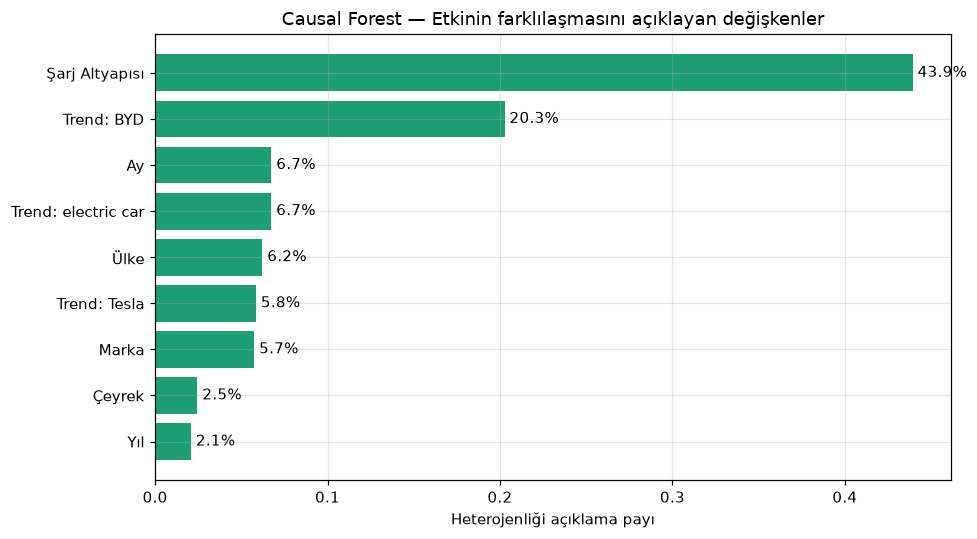


Şarj altyapısı çeyreğine göre:
             CATE      alt      ust    n
sarj_q                                  
Q1 Çok az  2707.0  -4668.0  10082.0  108
Q2 Az      3974.0  -3981.0  11930.0  108
Q3 Orta    3208.0  -6566.0  12982.0  108
Q4 Çok     5475.0 -34655.0  45605.0   96
seri       China – BYD  China – Tesla  France – All  Germany – VW  \
sarj_q                                                              
Q1 Çok az            0              0            12             0   
Q2 Az                0              0            24            12   
Q3 Orta              0              0            24            12   
Q4 Çok              48             36             0             0   

seri       India – All  Netherlands – All  Norway – BYD  USA – Tesla  \
sarj_q                                                                 
Q1 Çok az           60                  0            12            0   
Q2 Az                0                 24            12            0   
Q3 Orta            

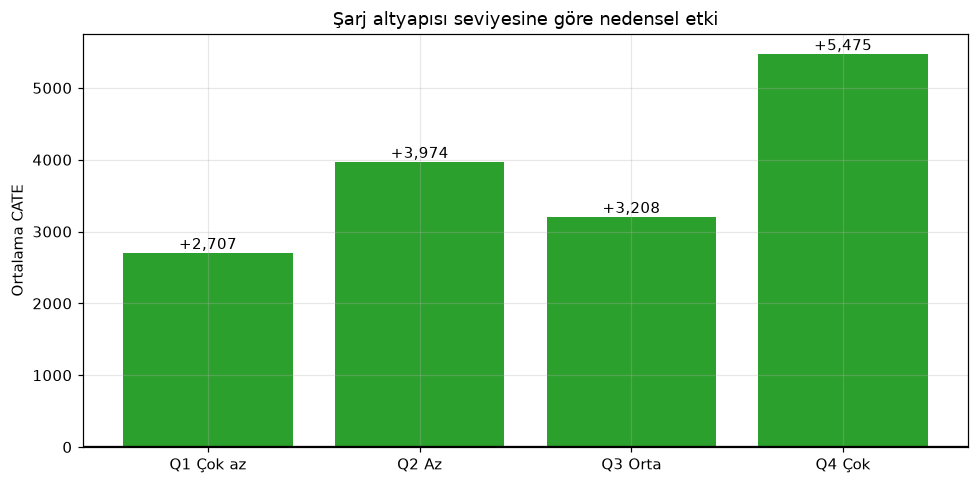

In [18]:
fi = pd.Series(cf.feature_importances_, index=conf_ad).sort_values(ascending=True)   # isimler conf sırasından
print('Causal Forest değişken önemi:'); print((fi[::-1] * 100).round(1))
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(fi.index, fi.values, color='#1D9E75')
for k, v in enumerate(fi.values): ax.text(v, k, f' {v:.1%}', va='center')
ax.set_xlabel('Heterojenliği açıklama payı'); ax.set_title('Causal Forest — Etkinin farklılaşmasını açıklayan değişkenler')
plt.tight_layout(); plt.savefig('grafikler/17_cf_onem.png', dpi=150, bbox_inches='tight'); plt.show()
SONUC['cf_onem'] = {k: round(float(v) * 100, 1) for k, v in fi[::-1].items()}

dc['sarj_q'] = pd.qcut(dc['total_chargers_cumulative'], 4, labels=['Q1 Çok az', 'Q2 Az', 'Q3 Orta', 'Q4 Çok'])
sarj = grup_ozet('sarj_q'); print('\nŞarj altyapısı çeyreğine göre:'); print(sarj.round(0))
print(pd.crosstab(dc['sarj_q'], dc['seri']))
r_sarj = float(np.corrcoef(dc['total_chargers_cumulative'], dc['cate'])[0, 1])
r_trend = float(np.corrcoef(dc['trend_electric_car'], dc['cate'])[0, 1])
r_sarj_s = float(dc[['total_chargers_cumulative', 'cate']].corr(method='spearman').iloc[0, 1])
print(f'\nKorelasyon — şarj altyapısı × CATE: r = {r_sarj:+.2f} (Spearman {r_sarj_s:+.2f})')
print(f'Korelasyon — "electric car" trendi × CATE: r = {r_trend:+.2f}')
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(sarj.index.astype(str), sarj['CATE'], color=['#2ca02c' if v > 0 else '#d62728' for v in sarj['CATE']])
ax.axhline(0, color='black'); ax.set_ylabel('Ortalama CATE'); ax.set_title('Şarj altyapısı seviyesine göre nedensel etki')
for k, v in enumerate(sarj['CATE']): ax.text(k, v, f'{v:+,.0f}', ha='center', va='bottom' if v > 0 else 'top')
plt.tight_layout(); plt.savefig('grafikler/18_cate_sarj.png', dpi=150, bbox_inches='tight'); plt.show()
SONUC['cate_sarj'] = sarj.round(0).to_dict(orient='index')
SONUC['sarj_seri_dagilim'] = pd.crosstab(dc['sarj_q'], dc['seri']).to_dict(orient='index')
SONUC['r'] = {'sarj': r_sarj, 'sarj_spearman': r_sarj_s, 'trend': r_trend}

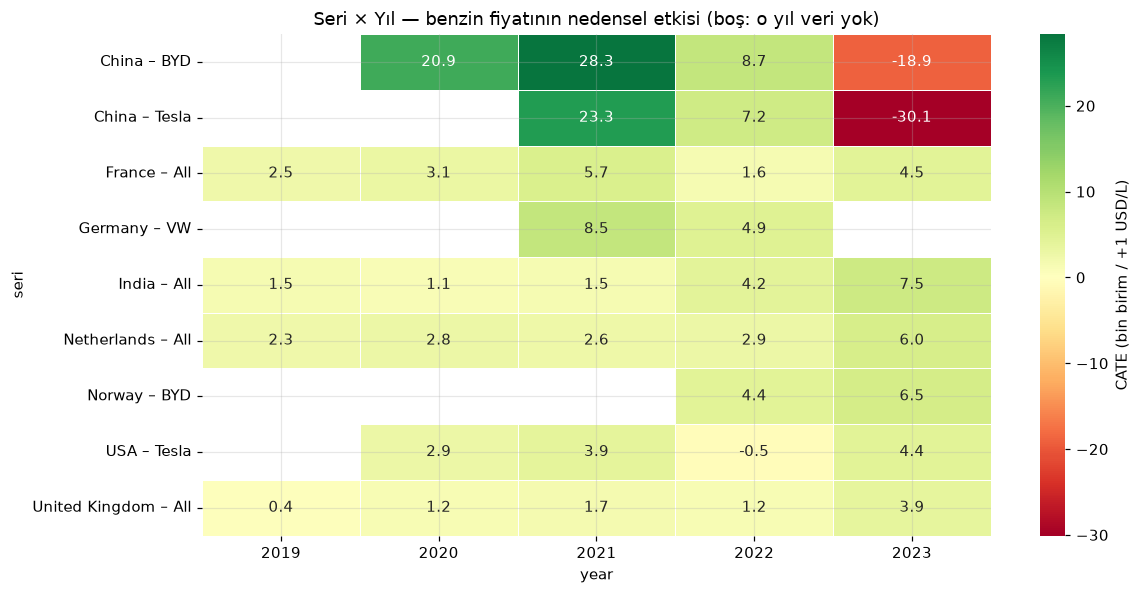

year                  2019  2020  2021  2022  2023
seri                                              
China – BYD            NaN  20.9  28.3   8.7 -18.9
China – Tesla          NaN   NaN  23.3   7.2 -30.1
France – All           2.5   3.1   5.7   1.6   4.5
Germany – VW           NaN   NaN   8.5   4.9   NaN
India – All            1.5   1.1   1.5   4.2   7.5
Netherlands – All      2.3   2.8   2.6   2.9   6.0
Norway – BYD           NaN   NaN   NaN   4.4   6.5
USA – Tesla            NaN   2.9   3.9  -0.5   4.4
United Kingdom – All   0.4   1.2   1.7   1.2   3.9


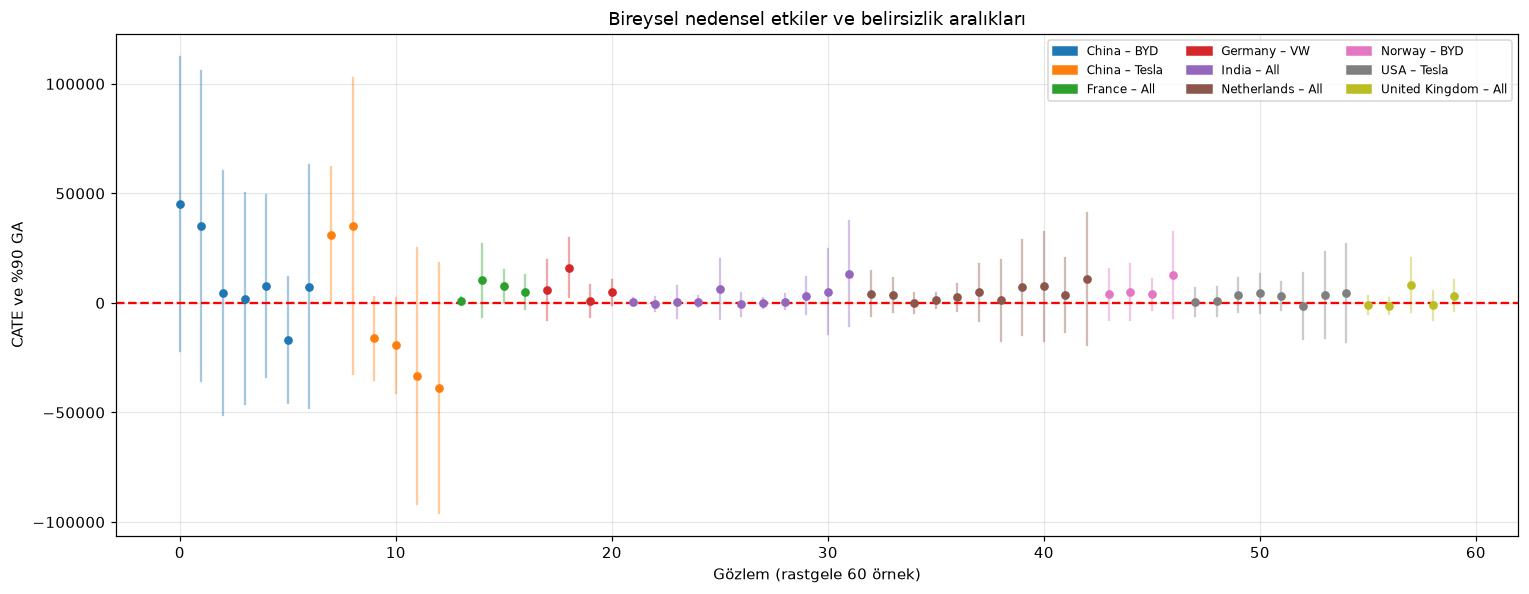

Seri bazında ortalama %90 GA genişliği:
seri
United Kingdom – All    13737.0
France – All            14614.0
India – All             16404.0
Norway – BYD            17605.0
Netherlands – All       18534.0
Germany – VW            20997.0
USA – Tesla             24911.0
China – BYD             83858.0
China – Tesla           88413.0
Name: genislik, dtype: float64


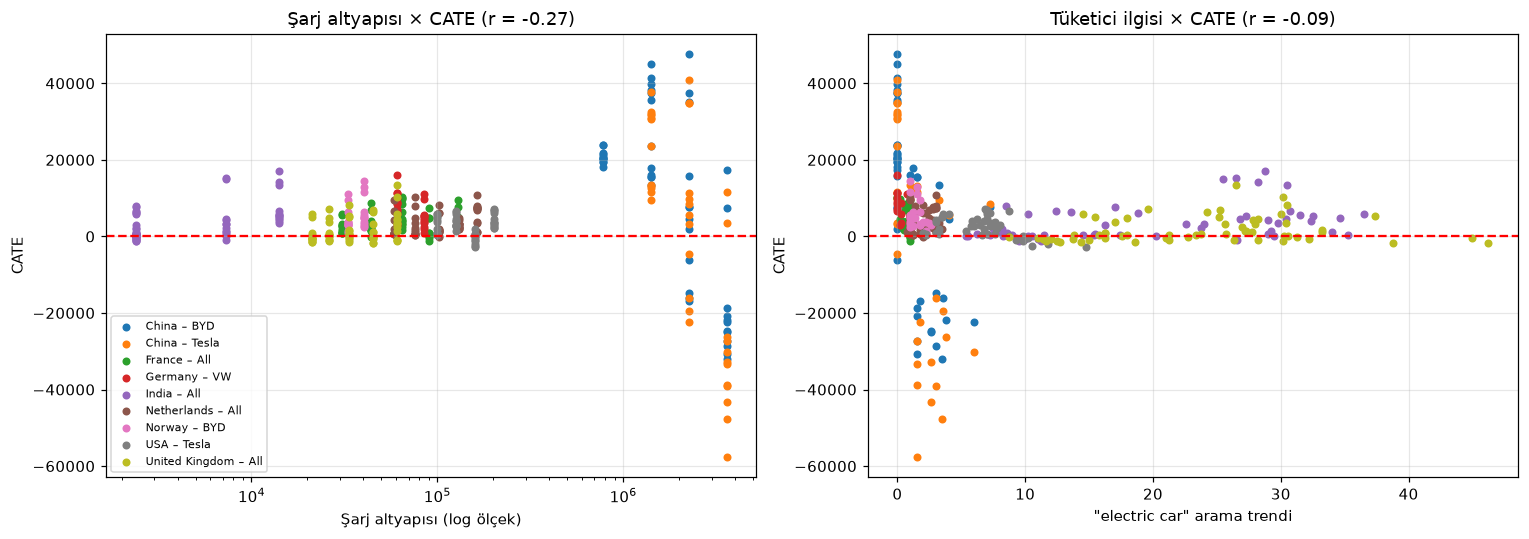

In [19]:
pivot = dc.pivot_table(values='cate', index='seri', columns='year', aggfunc='mean')
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.heatmap(pivot / 1000, annot=True, fmt='.1f', cmap='RdYlGn', center=0, linewidths=.5, ax=ax,
            cbar_kws={'label': 'CATE (bin birim / +1 USD/L)'})
ax.set_title('Seri × Yıl — benzin fiyatının nedensel etkisi (boş: o yıl veri yok)')
plt.tight_layout(); plt.savefig('grafikler/19_cate_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()
print((pivot / 1000).round(1))
SONUC['cate_pivot_bin'] = (pivot / 1000).round(1).to_dict(orient='index')

rng = np.random.default_rng(42)
idx = np.sort(rng.choice(len(dc), 60, replace=False))
renk = dict(zip(sorted(dc['seri'].unique()), plt.cm.tab10.colors))
fig, ax = plt.subplots(figsize=(14, 5.5))
for k, i in enumerate(idx):
    c = renk[dc['seri'].iloc[i]]
    ax.plot([k, k], [lb[i], ub[i]], color=c, alpha=.4); ax.scatter(k, dc['cate'].iloc[i], color=c, s=22, zorder=3)
ax.axhline(0, color='red', ls='--', label='Sıfır etki')
ax.legend(handles=[mpatches.Patch(color=v, label=k) for k, v in renk.items()], fontsize=8, ncol=3)
ax.set_xlabel('Gözlem (rastgele 60 örnek)'); ax.set_ylabel('CATE ve %90 GA')
ax.set_title('Bireysel nedensel etkiler ve belirsizlik aralıkları')
plt.tight_layout(); plt.savefig('grafikler/20_cate_ci.png', dpi=150, bbox_inches='tight'); plt.show()
ga = dc.assign(genislik=ub - lb).groupby('seri')['genislik'].mean().sort_values()
print('Seri bazında ortalama %90 GA genişliği:'); print(ga.round(0))
SONUC['ga_genislik'] = ga.round(0).to_dict()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for s in renk:
    m = dc['seri'] == s
    axes[0].scatter(dc.loc[m, 'total_chargers_cumulative'], dc.loc[m, 'cate'], s=18, color=renk[s], label=s)
    axes[1].scatter(dc.loc[m, 'trend_electric_car'], dc.loc[m, 'cate'], s=18, color=renk[s])
axes[0].set_xscale('log'); axes[0].set_xlabel('Şarj altyapısı (log ölçek)'); axes[1].set_xlabel('"electric car" arama trendi')
for a in axes: a.axhline(0, color='red', ls='--'); a.set_ylabel('CATE')
axes[0].legend(fontsize=7); axes[0].set_title(f'Şarj altyapısı × CATE (r = {r_sarj:+.2f})')
axes[1].set_title(f'Tüketici ilgisi × CATE (r = {r_trend:+.2f})')
plt.tight_layout(); plt.savefig('grafikler/21_cate_sarj_trend.png', dpi=150, bbox_inches='tight'); plt.show()

+0.3 USD/L senaryosu (artış oranı: %22):
                      aylik_etki      alt      ust  ort_satis  etki_%
seri                                                                 
China – BYD               2923.4  -9655.3  15502.1   264489.0     1.1
Germany – VW              2008.1  -1141.4   5157.7    23328.9     8.6
Norway – BYD              1636.1  -1004.6   4276.8     1255.1   130.4
France – All              1044.0  -1148.1   3236.0    23198.4     4.5
Netherlands – All         1001.2  -1778.9   3781.3     7610.2    13.2
India – All                949.0  -1511.6   3409.7     2676.2    35.5
USA – Tesla                807.0  -2929.7   4543.7    89315.8     0.9
United Kingdom – All       506.6  -1554.0   2567.1    23448.2     2.2
China – Tesla               42.4 -13219.6  13304.4    47321.7     0.1


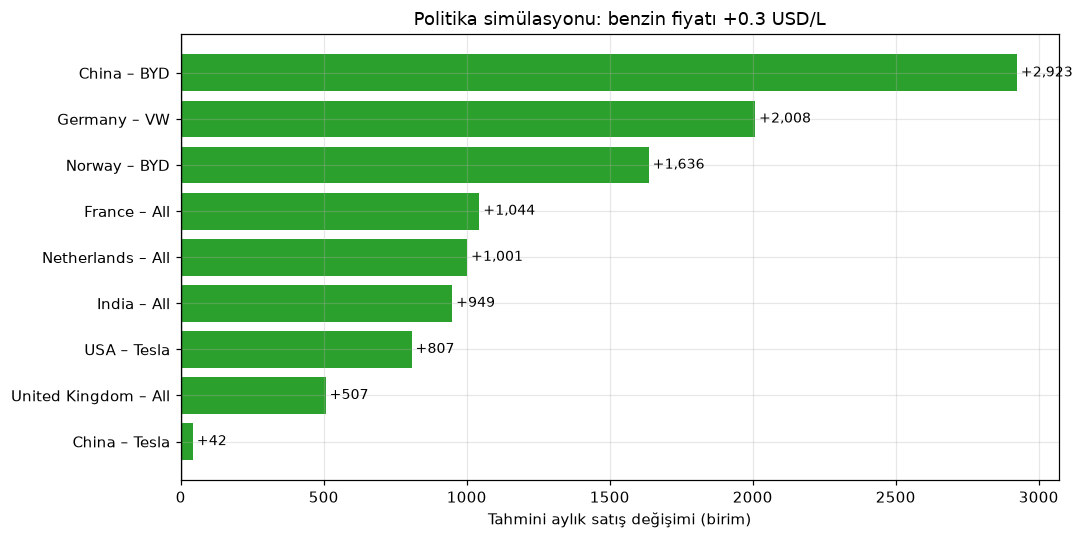

In [20]:
# Politika simülasyonu: benzin fiyatı +0.30 USD/L (ortalama fiyatın ~%22'si)
delta = 0.30
dc['sim'] = dc['cate'] * delta
sim = dc.groupby('seri').agg(aylik_etki=('sim', 'mean'), alt=('cate_lb', lambda s: s.mean() * delta),
                             ust=('cate_ub', lambda s: s.mean() * delta), ort_satis=('units_sold', 'mean'))
sim['etki_%'] = sim['aylik_etki'] / sim['ort_satis'] * 100
sim = sim.sort_values('aylik_etki', ascending=False)
print(f'+{delta} USD/L senaryosu (artış oranı: %{delta / T.mean() * 100:.0f}):'); print(sim.round(1))
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(sim.index[::-1], sim['aylik_etki'][::-1], color=['#2ca02c' if v > 0 else '#d62728' for v in sim['aylik_etki'][::-1]])
ax.axvline(0, color='black'); ax.set_xlabel('Tahmini aylık satış değişimi (birim)')
ax.set_title(f'Politika simülasyonu: benzin fiyatı +{delta} USD/L')
for k, v in enumerate(sim['aylik_etki'][::-1]): ax.text(v, k, f' {v:+,.0f} ', va='center', ha='left' if v > 0 else 'right', fontsize=9)
plt.tight_layout(); plt.savefig('grafikler/22_politika_sim.png', dpi=150, bbox_inches='tight'); plt.show()
SONUC['sim'] = {'delta': delta, 'oran': float(delta / T.mean() * 100), 'tablo': sim.round(1).to_dict(orient='index')}

## 7. Sağlamlık kontrolü: logaritmik satış
Satışlar seriden seriye 1.000 kat farklı olduğu için (Norveç–BYD ≈ 1 bin, Çin–BYD ≈ 260 bin) ham birimde ortalama etki büyük serilere göre şekillenir. Aynı modeli `log(units_sold)` ile kurarak etkiyi **yüzde değişim** olarak ölçüyoruz.

In [21]:
Ylog = np.log(Y)
dml_log = LinearDML(model_y=RandomForestRegressor(n_estimators=200, random_state=42),
                    model_t=RandomForestRegressor(n_estimators=200, random_state=42), random_state=42, cv=5)
dml_log.fit(Ylog, T, X=X)
a = float(dml_log.ate(X)); al, au = (float(v) for v in dml_log.ate_interval(X, alpha=0.05))
pct = lambda b: (np.exp(b * 0.10) - 1) * 100
print(f'log-ATE: {a:+.3f} → benzin +0.10 USD/L iken satış %{pct(a):+.1f}  (95% GA: %{pct(al):+.1f} … %{pct(au):+.1f})')
SONUC['log_dml'] = {'ate': a, 'lb': al, 'ub': au, 'pct10': pct(a), 'pct10_lb': pct(al), 'pct10_ub': pct(au)}

with open('sonuclar.json', 'w', encoding='utf-8') as f:
    json.dump(SONUC, f, ensure_ascii=False, indent=1, default=lambda o: o.item() if hasattr(o, 'item') else str(o))
print('Tüm sonuçlar sonuclar.json dosyasına kaydedildi.')

log-ATE: +0.146 → benzin +0.10 USD/L iken satış %+1.5  (95% GA: %-3.5 … %+6.7)
Tüm sonuçlar sonuclar.json dosyasına kaydedildi.
